# Regressão 01 - tarefa 01

### 1. Explorando a base de gorjetas

a. Na aula fizemos uma regressão de ```tip``` explicada por ```net_bill```. Carregue os pacotes e a base, crie as variáveis necessárias como na aula, e reproduza esta regressão.

b. Reproduza também o gráfico de dispersão dessas duas variáveis.

Intercept    1.330698
net_bill     0.099334
dtype: float64

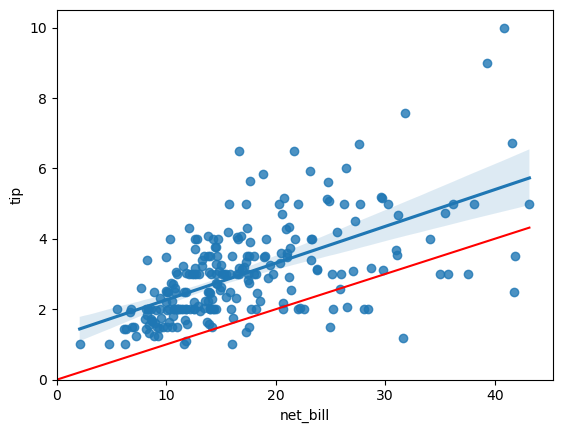

In [1]:
import pandas as pd
import seaborn as sns
from seaborn import load_dataset

import matplotlib.pyplot as plt

import numpy as np

import statsmodels.formula.api as smf

tips = sns.load_dataset("tips")
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips.head()

# Gráfico de dispersão
sns.regplot(y = 'tip', x = 'net_bill', data = tips[tips['tip_pct']<.5])

# Gerando dados para a linha dos 10%
x = np.linspace(0,tips['net_bill'].max(),100)
y = .1*x

# Plotando a linha dos 10%
plt.plot(x, y, '-r', label='linha dos 10%')

# Opções estéticas para explicitar o (0,0) no gráfico
plt.xlim(left = 0)
plt.ylim(bottom = 0)

reg = smf.ols('tip ~ net_bill', data = tips).fit()
reg.summary()

dados_novos = tips[0:5]
dados_novos

# Predição de dados novos
reg.predict(dados_novos)

# Onde o Python guarda os parâmetros?
reg.params

### 2. Mudança de perspectiva

Agora ajuste um modelo de regressão de ```tip_pct``` por ```net_bill```. Construa o gráfico de dispersão correspondente.

                            OLS Regression Results                            
Dep. Variable:           perc_gorjeta   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     56.10
Date:                Thu, 21 Nov 2024   Prob (F-statistic):           1.31e-12
Time:                        12:41:12   Log-Likelihood:                 331.48
No. Observations:                 242   AIC:                            -659.0
Df Residuals:                     240   BIC:                            -652.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.2538      0.009     27.252

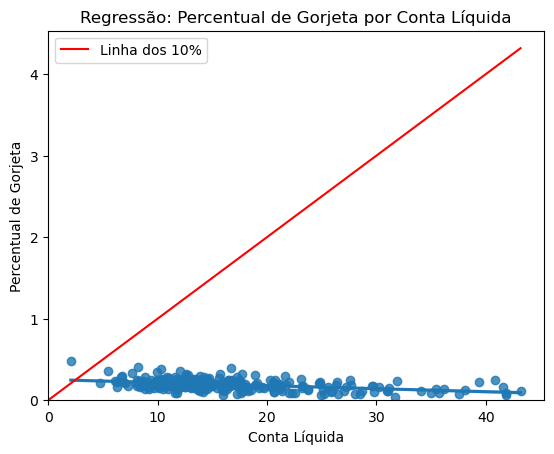

In [3]:
# Carregar o dataset
gorjetas = sns.load_dataset("tips")

# Criar novas colunas
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['perc_gorjeta'] < 0.5]

# Gráfico de dispersão
sns.regplot(y='perc_gorjeta', x='conta_liquida', data=dados_filtrados)

# Ajustar modelo de regressão
modelo = smf.ols('perc_gorjeta ~ conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo.summary())

# Adicionar linha de 10% ao gráfico para comparação
x = np.linspace(0, gorjetas['conta_liquida'].max(), 100)
y = 0.1  # Representa uma gorjeta de 10% fixa em relação ao valor líquido
plt.plot(x, y * x, '-r', label='Linha dos 10%')

# Melhorar estética do gráfico
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel('Conta Líquida')
plt.ylabel('Percentual de Gorjeta')
plt.title('Regressão: Percentual de Gorjeta por Conta Líquida')
plt.legend()

# Exibir o gráfico
plt.show()

### 3. Comente

Compare os dois gráficos e comente (de forma objetiva e suscinta) a relação entre eles e a diferença do ajuste. Podemos comparar diretamente os $R^2$s?

Os dois gráficos apresentam diferentes relações. No primeiro, que relaciona o valor absoluto da gorjeta com a conta líquida, observa-se uma tendência linear clara, em que gorjetas aumentam proporcionalmente ao valor da conta. Isso é esperado, já que contas maiores tendem a gerar gorjetas mais altas em termos absolutos. O modelo ajustado reflete bem essa relação com um R² mais elevado, indicando que a variabilidade na gorjeta pode ser explicada principalmente pelo valor da conta líquida.

No segundo gráfico, que relaciona o percentual da gorjeta com a conta líquida, a tendência é diferente: contas mais altas tendem a receber percentuais menores de gorjeta. Essa relação não é tão bem ajustada por um modelo linear, resultando em um R² menor, pois o comportamento do percentual de gorjeta apresenta maior dispersão e não segue um padrão linear claro. Comparar os R² entre os dois modelos não é apropriado, já que as variáveis dependentes são diferentes, uma representando valores absolutos e outra percentuais. Cada R² reflete apenas o ajuste dentro do contexto da variável dependente utilizada.

### 4. Ajuste do modelo em outra escala

Com o modelo no item 3, obtenha a preditiva do valor da gorjeta:
  1. obtenha o valor predito ```pred``` para ```tip_pct``` (dica, veja o atributo ```reg.fittedvalues```)
  2. obtenha o valor predito para ```tip``` como ```tip_pct * net_bill```
  3. calcule o $R^2$ do modelo para ```tip```
  4. compare esse $R^2$ com o do item 1

In [11]:
# Criar manualmente um conjunto de dados similar ao "tips"
dados = {
    "total_bill": [16.99, 10.34, 21.01, 23.68, 24.59],
    "tip": [1.01, 1.66, 3.50, 3.31, 3.61],
    "size": [2, 3, 3, 2, 4]
}

# Criar DataFrame
gorjetas = pd.DataFrame(dados)

# Criar colunas adicionais
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Ajustar o modelo para perc_gorjeta ~ conta_liquida
modelo_perc = smf.ols('perc_gorjeta ~ conta_liquida', data=gorjetas).fit()

# Obter os valores preditos para perc_gorjeta (tip_pct)
gorjetas['pred_perc_gorjeta'] = modelo_perc.fittedvalues

# Calcular os valores preditos para gorjeta (tip) como perc_gorjeta * conta_liquida
gorjetas['pred_gorjeta'] = gorjetas['pred_perc_gorjeta'] * gorjetas['conta_liquida']

# Calcular o R² do modelo para gorjeta (tip) usando os valores reais e preditos
from sklearn.metrics import r2_score
r2_gorjeta_ajustado = r2_score(gorjetas['tip'], gorjetas['pred_gorjeta'])

# Ajustar o modelo original tip ~ conta_liquida para obter o R² original
modelo_original = smf.ols('tip ~ conta_liquida', data=gorjetas).fit()
r2_gorjeta_original = modelo_original.rsquared

# Exibir os R² ajustado e original
r2_gorjeta_ajustado, r2_gorjeta_original


(0.4600404258743106, 0.4778315398349221)